Epoch 1, Loss: 0.1787
Epoch 2, Loss: 0.0035
Epoch 3, Loss: 0.0022
Epoch 4, Loss: 0.0015
Epoch 5, Loss: 0.0012
Training Finished!


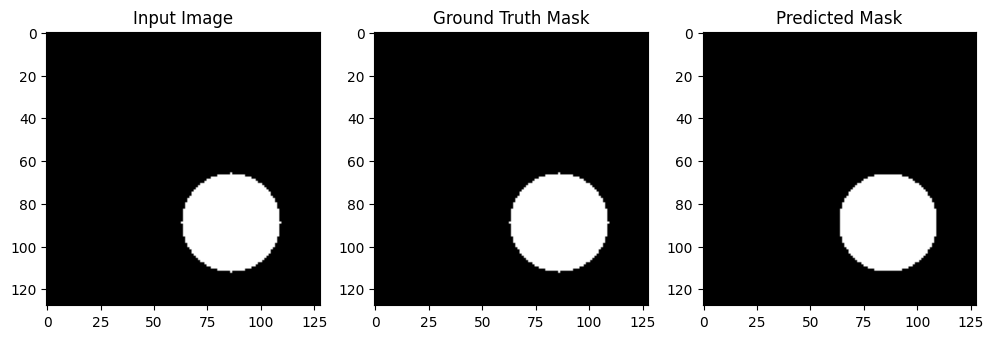

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import random

# ------------------------------
# 1. Create Synthetic Dataset
# ------------------------------

class CircleDataset(Dataset):
    def __init__(self, num_samples=200, img_size=128):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img = np.zeros((self.img_size, self.img_size))
        mask = np.zeros((self.img_size, self.img_size))

        # Random circle parameters
        radius = random.randint(10, 30)
        center_x = random.randint(radius, self.img_size - radius)
        center_y = random.randint(radius, self.img_size - radius)

        for x in range(self.img_size):
            for y in range(self.img_size):
                if (x - center_x) ** 2 + (y - center_y) ** 2 <= radius ** 2:
                    img[x, y] = 1.0
                    mask[x, y] = 1.0

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)

        return img, mask


# ------------------------------
# 2. Double Convolution Block
# ------------------------------

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


# ------------------------------
# 3. U-Net Architecture
# ------------------------------

class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottom = DoubleConv(128, 256)

        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        bottom = self.bottom(p2)

        up1 = self.up1(bottom)
        merge1 = torch.cat([up1, d2], dim=1)
        c1 = self.conv1(merge1)

        up2 = self.up2(c1)
        merge2 = torch.cat([up2, d1], dim=1)
        c2 = self.conv2(merge2)

        out = self.final(c2)
        return out


# ------------------------------
# 4. Training Setup
# ------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

dataset = CircleDataset()
loader = DataLoader(dataset, batch_size=8, shuffle=True)

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ------------------------------
# 5. Training Loop
# ------------------------------

epochs = 5

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for imgs, masks in loader:
        imgs = imgs.to(device)
        masks = masks.to(device)

        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

print("Training Finished!")


# ------------------------------
# 6. Visualization
# ------------------------------

model.eval()
sample_img, sample_mask = dataset[0]
sample_img = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    pred = model(sample_img)
    pred = torch.sigmoid(pred)
    pred = pred.cpu().squeeze().numpy()
    pred = (pred > 0.5).astype(np.float32)

sample_img = sample_img.cpu().squeeze().numpy()
sample_mask = sample_mask.squeeze().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Input Image")
plt.imshow(sample_img, cmap='gray')

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(sample_mask, cmap='gray')

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pred, cmap='gray')

plt.show()